<span style="font-size:24px; font-weight:bold">✈️ Airline Customer Satisfaction Prediction</span>


This project aims to classify whether a customer is satisfied based on features like gender, customer type, age, class, type of travel, flight distance, and various service ratings.  
We will perform **data cleaning**, **exploratory data analysis (EDA)**, and build a **Decision Tree classifier** to predict satisfaction levels.


<span style="font-size:20px; font-weight:bold">📥 Step 1: Importing Libraries & Dataset</span>


In [9]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
import warnings 
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import precision_score,recall_score,classification_report,confusion_matrix,f1_score,accuracy_score

In [3]:
df=pd.read_csv(r"C:\Users\desai\Downloads\ML Project - Decision Tree Airline Customer Satisfaction U16955468980.txt")

In [4]:
df.isnull().sum()

Unnamed: 0.1                          0
Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             26


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0.1                       10000 non-null  int64  
 1   Unnamed: 0                         10000 non-null  int64  
 2   id                                 10000 non-null  int64  
 3   Gender                             10000 non-null  object 
 4   Customer Type                      10000 non-null  object 
 5   Age                                10000 non-null  int64  
 6   Type of Travel                     10000 non-null  object 
 7   Class                              10000 non-null  object 
 8   Flight Distance                    10000 non-null  int64  
 9   Inflight wifi service              10000 non-null  int64  
 10  Departure/Arrival time convenient  10000 non-null  int64  
 11  Ease of Online booking             10000 non-null  int6

In [6]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9974.000000
mean,4999.50000,4999.50000,64950.978500,39.303700,1198.823800,2.731500,3.038900,2.753600,2.96890,3.208800,...,3.411300,3.335500,3.366000,3.346500,3.619900,3.285600,3.627400,3.268200,14.785400,15.242130
std,2886.89568,2886.89568,37420.905082,15.116478,1001.774138,1.328226,1.528077,1.403241,1.28425,1.339769,...,1.326012,1.340567,1.288336,1.311415,1.190028,1.269013,1.181401,1.321077,38.217509,38.810195
min,0.00000,0.00000,8.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2499.75000,2499.75000,32330.500000,27.000000,413.000000,2.000000,2.000000,2.000000,2.00000,2.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,4999.50000,4999.50000,64941.000000,40.000000,852.500000,3.000000,3.000000,3.000000,3.00000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,7499.25000,7499.25000,97579.750000,51.000000,1747.000000,4.000000,4.000000,4.000000,4.00000,4.000000,...,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,13.000000,13.000000
max,9999.00000,9999.00000,129863.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.00000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1305.000000,1280.000000


In [7]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [8]:
df.head()

,Unnamed: 0.1,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [9]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [10]:
df

,Unnamed: 0.1,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,124365,Male,Loyal Customer,50,Business travel,Business,3599,3,3,...,5,5,5,5,5,5,4,12,24.0,satisfied
9996,9996,22044,Male,Loyal Customer,38,Business travel,Business,3873,5,5,...,4,4,4,4,3,4,5,0,0.0,satisfied
9997,9997,14057,Female,Loyal Customer,39,Business travel,Business,319,4,4,...,4,4,4,4,3,4,2,0,0.0,satisfied
9998,9998,113848,Male,Loyal Customer,52,Business travel,Business,1363,5,5,...,4,4,3,4,5,4,5,1,11.0,satisfied


In [11]:
df.columns=[each.replace(" ","_") for each in df.columns]

In [12]:
df.columns

Index(['Unnamed:_0.1', 'id', 'Gender', 'Customer_Type', 'Age',
       'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='object')

In [13]:
df["satisfaction"]=[1 if each=="satisfied" else 0 for each in df.satisfaction]

In [14]:
df["Arrival_Delay_in_Minutes"].value_counts()

Arrival_Delay_in_Minutes
0.0      5531
1.0       207
2.0       199
4.0       184
3.0       182
         ... 
259.0       1
257.0       1
203.0       1
354.0       1
244.0       1
Name: count, Length: 251, dtype: int64

In [52]:
df=df.dropna()

In [54]:
df.isnull().sum()

Unnamed:_0.1                         0
id                                   0
Gender                               0
Customer_Type                        0
Age                                  0
Type_of_Travel                       0
Class                                0
Flight_Distance                      0
Inflight_wifi_service                0
Departure/Arrival_time_convenient    0
Ease_of_Online_booking               0
Gate_location                        0
Food_and_drink                       0
Online_boarding                      0
Seat_comfort                         0
Inflight_entertainment               0
On-board_service                     0
Leg_room_service                     0
Baggage_handling                     0
Checkin_service                      0
Inflight_service                     0
Cleanliness                          0
Departure_Delay_in_Minutes           0
Arrival_Delay_in_Minutes             0
satisfaction                         0
dtype: int64

In [60]:
df["Flight_Distance"].unique()

array([ 460,  235, 1142, ..., 3033, 1319, 1443], dtype=int64)

In [16]:
df["satisfaction"].value_counts()

satisfaction
0    5689
1    4311
Name: count, dtype: int64

<Axes: xlabel='satisfaction', ylabel='count'>

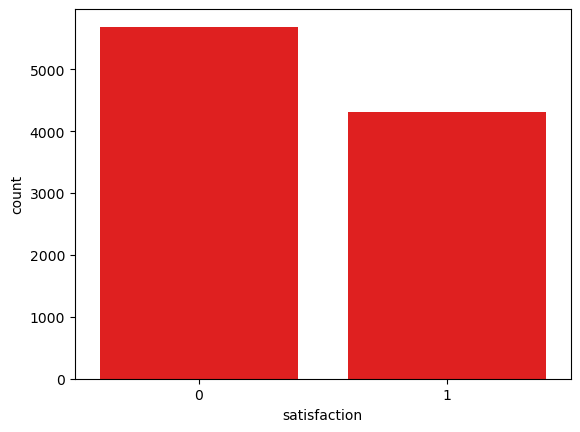

In [18]:
sns.barplot(df["satisfaction"].value_counts(),color="r")

In [19]:
df[["Gender","satisfaction"]].groupby(["Gender"],as_index=False).value_counts().sort_values(by="satisfaction",ascending=False)

,Gender,satisfaction,count
1,Female,1,2168
3,Male,1,2143
0,Female,0,2940
2,Male,0,2749


In [20]:
df[["Age","satisfaction"]].groupby(["Age"],as_index=False).value_counts().sort_values(by="satisfaction",ascending=False)

,Age,satisfaction,count
121,67,1,10
111,62,1,21
66,40,1,150
113,63,1,14
64,39,1,134
...,...,...,...
58,36,0,132
56,35,0,118
54,34,0,119
52,33,0,111


In [21]:
df[["Food_and_drink","satisfaction"]].groupby(["Food_and_drink"],as_index=False).value_counts().sort_values(by="satisfaction",ascending=False)

,Food_and_drink,satisfaction,count
0,0,1,5
3,1,1,256
5,2,1,742
7,3,1,844
8,4,1,1232
10,5,1,1232
1,0,0,3
2,1,0,1036
4,2,0,1306
6,3,0,1240


In [22]:
#11) Display a boxplot for Flight_Distance 
# 12) Display a boxplot for Checkin_service 

<Axes: ylabel='Flight_Distance'>

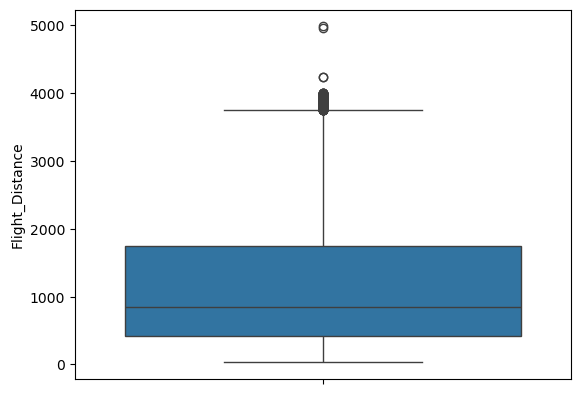

In [23]:
sns.boxplot(df["Flight_Distance"])

<Axes: ylabel='Checkin_service'>

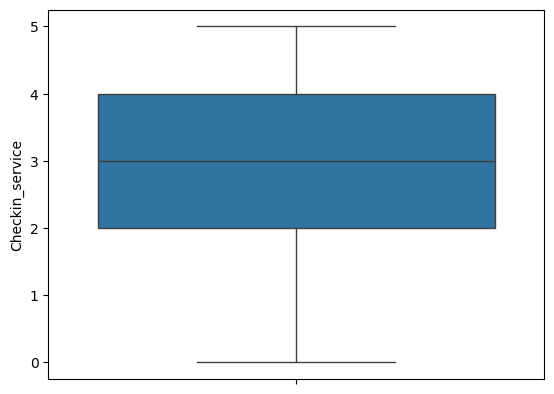

In [24]:
sns.boxplot(df["Checkin_service"])

In [ ]:
#Perform encoding in columns Gender, Customer_Type, Type_of_Travel, and Class. 

In [76]:
enc=LabelEncoder()


In [78]:
df["Gender"]=enc.fit_transform(df["Gender"])

In [82]:
df["Customer_Type"]=enc.fit_transform(df["Customer_Type"])

In [88]:
df["Type_of_Travel"]=enc.fit_transform(df["Type_of_Travel"])
df['Class'] = enc.fit_transform(df['Class'])

In [90]:
df

,Unnamed:_0.1,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,70172,1,0,13,1,2,460,3,4,...,5,4,3,4,4,5,5,25,18.0,0
1,1,5047,1,1,25,0,0,235,3,2,...,1,1,5,3,1,4,1,1,6.0,0
2,2,110028,0,0,26,0,0,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,3,24026,0,0,25,0,0,562,2,5,...,2,2,5,3,1,4,2,11,9.0,0
4,4,119299,1,0,61,0,0,214,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,124365,1,0,50,0,0,3599,3,3,...,5,5,5,5,5,5,4,12,24.0,1
9996,9996,22044,1,0,38,0,0,3873,5,5,...,4,4,4,4,3,4,5,0,0.0,1
9997,9997,14057,0,0,39,0,0,319,4,4,...,4,4,4,4,3,4,2,0,0.0,1
9998,9998,113848,1,0,52,0,0,1363,5,5,...,4,4,3,4,5,4,5,1,11.0,1


In [96]:
df=df.drop(["Unnamed:_0.1","id"],axis=1)

In [98]:
df

,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,0,50,0,0,3599,3,3,3,3,...,5,5,5,5,5,5,4,12,24.0,1
9996,1,0,38,0,0,3873,5,5,5,5,...,4,4,4,4,3,4,5,0,0.0,1
9997,0,0,39,0,0,319,4,4,4,4,...,4,4,4,4,3,4,2,0,0.0,1
9998,1,0,52,0,0,1363,5,5,5,5,...,4,4,3,4,5,4,5,1,11.0,1


In [ ]:
#Perform scaling on features data 

In [108]:
x= df.drop('satisfaction',axis=1)
y= df['satisfaction']

In [102]:
sc=StandardScaler()

In [112]:
x=sc.fit_transform(x)

In [ ]:
#split the data into train test data 

In [122]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=42)

In [124]:
#fit the decision tree model with various parameters 

In [214]:
params = {'max_depth': 5,    
             'max_features': 5,
            'min_samples_leaf':1,
             'min_samples_split':2,
            'criterion':'gini'}


In [216]:
model=DecisionTreeClassifier(criterion="gini",max_depth=12,max_features="sqrt",min_samples_split=2,min_samples_leaf=1)

In [218]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=12, max_features='sqrt')

In [220]:
y_pred=model.predict(x_test)

In [222]:
model.score(x_train,y_train)

0.9670534307405816

In [224]:
model.score(x_test,y_test)

0.9101236217841631

In [226]:
from sklearn.tree import plot_tree

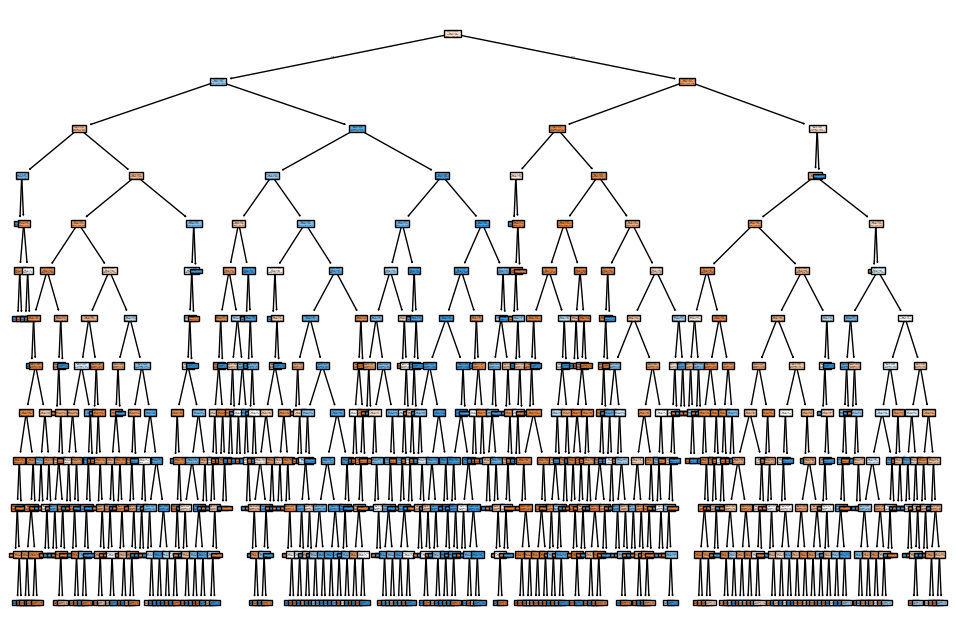

In [228]:
plt.figure(figsize=(12, 8))
plot_tree(model,filled=True)
plt.show()


In [ ]:
#find mean absolute error and mean squre error 

In [148]:
mae=mean_absolute_error(y_test,y_pred)

In [150]:
mae

0.0845305713331106

In [152]:
mse=mean_squared_error(y_test,y_pred)**1/2

In [154]:
mse

0.0422652856665553

In [156]:
#Create a function to display precision score, recall score, accuracy, classification report, confusion matrix, F1 Score.

In [184]:
print("accuresy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


accuresy_score: 0.9154694286668894
recall_score: 0.8987730061349694
f1_score: 0.9025798998844821
precision_score: 0.9064191802010828
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1689
           1       0.91      0.90      0.90      1304

    accuracy                           0.92      2993
   macro avg       0.91      0.91      0.91      2993
weighted avg       0.92      0.92      0.92      2993

[[1568  121]
 [ 132 1172]]


In [186]:
import seaborn as sns

In [188]:
cm=confusion_matrix(y_test,y_pred)

Text(0.5, 1.0, 'Confusion Matrix')

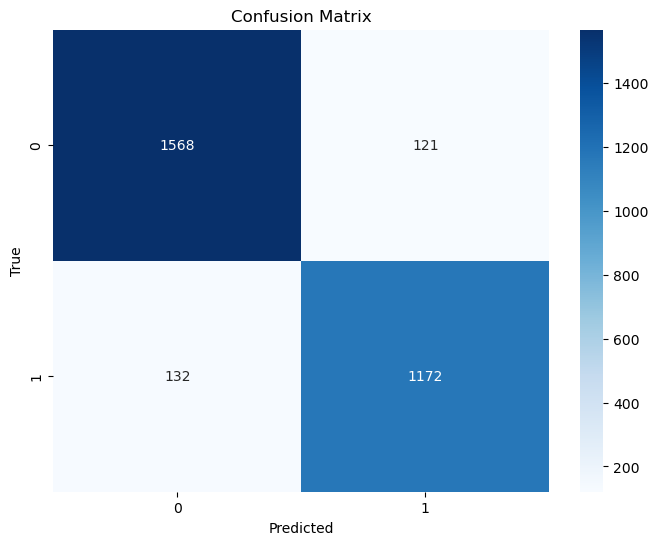

In [196]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')